In [25]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports test")

Imports test


In [26]:
DATA_PATH = "../data/predictive_maintenance.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [27]:
print(df.columns.tolist())
df.info()

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [28]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [29]:
print("Target counts:\n", df["Target"].value_counts())
print("\nTarget rate (mean):", round(df["Target"].mean(), 4))
print("\nTarget %:\n", (df["Target"].value_counts(normalize=True) * 100).round(2))

Target counts:
 Target
0    9661
1     339
Name: count, dtype: int64

Target rate (mean): 0.0339

Target %:
 Target
0    96.61
1     3.39
Name: proportion, dtype: float64


In [30]:
# If you see 'Failure Type' here, that's the leakage column we must drop.
df["Failure Type"].value_counts(dropna=False).head(10)

drop_cols = ["UDI", "Product ID", "Failure Type"]
df_model = df.drop(columns=drop_cols)

print("New shape after dropping leakage/IDs:", df_model.shape)
df_model.head()

New shape after dropping leakage/IDs: (10000, 7)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [31]:
y = df_model["Target"].astype(int)
X = df_model.drop(columns=["Target"])

# Encode machine Type (L/M/H)
X = pd.get_dummies(X, columns=["Type"], drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (10000, 7)
y shape: (10000,)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train failure rate:", round(y_train.mean(), 4))
print("Test failure rate:", round(y_test.mean(), 4))

Train shape: (7500, 7) Test shape: (2500, 7)
Train failure rate: 0.0339
Test failure rate: 0.034


In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression")
print("Accuracy:", round(lr_acc, 4))
print("F1:", round(lr_f1, 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))

Logistic Regression
Accuracy: 0.8252
F1: 0.2373
Confusion Matrix:
 [[1995  420]
 [  17   68]]


### Baseline Model Interpretation

Logistic Regression establishes a simple interpretable baseline.
Due to class imbalance (~3.4% failures), F1-score is used instead
of accuracy to evaluate performance.

The model prioritizes detecting failures while accepting some
false positives, which aligns with predictive maintenance goals.

### XGBOOST MODEL IMPLEMENTATION

XGBoost
Accuracy: 0.9812
F1: 0.7374
Confusion Matrix:
 [[2387   28]
 [  19   66]]


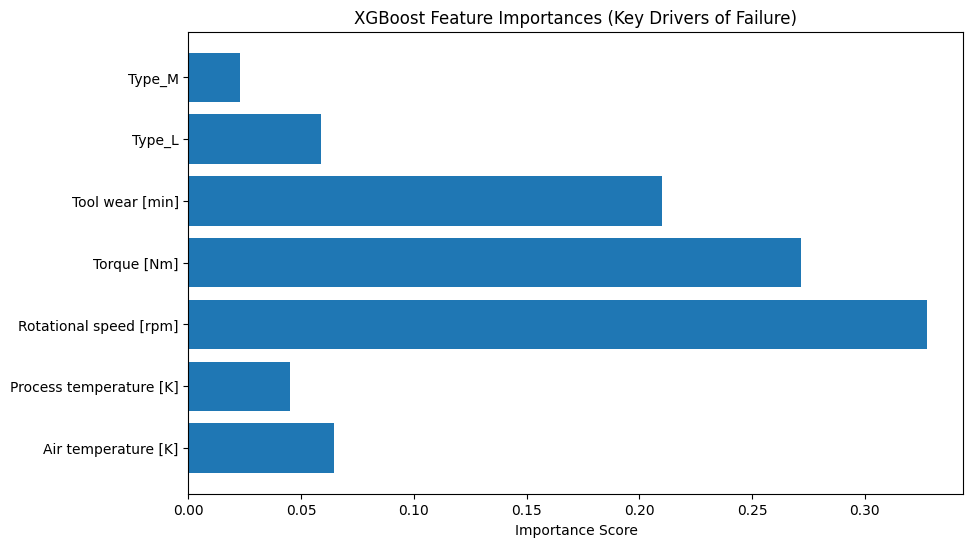

In [34]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb.fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("XGBoost")
print("Accuracy:", round(xgb_acc, 4))
print("F1:", round(xgb_f1, 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))

plt.figure(figsize=(10, 6))
plt.barh(X.columns, xgb.feature_importances_)
plt.title("XGBoost Feature Importances (Key Drivers of Failure)")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
# ==========================================
# PHASE 3: THE ADVANCED PENSKE AI AGENT
# ==========================================
import os
import getpass
import numpy as np
import pandas as pd

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# API key
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

# store important notebook objects
STATE = {
    
    "df": df,
    "X_cols": list(X.columns),

    "scaler": scaler,

    "lr_model": lr,
    "xgb_model": xgb,

    "X_test": X_test,
    "X_test_scaled": X_test_scaled,
    "y_test": y_test
}


# TOOL 1: EDA SUMMARY

@tool
def eda_tool(query: str) -> str:
    """
    Use this tool for ANY question about the dataset itself.
    Examples: "EDA", "summarize the data", "what columns exist", "is the target imbalanced",
    "are there missing values", "which features correlate with Target".
    Output should include ONLY:
    - dataset shape
    - Target class distribution (counts + %)
    - missing values summary
    - top correlations with Target
    -Whatever you may see fit to answer the quetions
    
    The dataset is already loaded in STATE['df'] with binary target column 'Target'.
    """
  

    df_local = STATE["df"]

    report = []

    report.append(f"Dataset shape: {df_local.shape[0]} rows, {df_local.shape[1]} columns\n")

    target_counts = df_local["Target"].value_counts()
    target_pct = (target_counts / len(df_local) * 100).round(2)

    report.append("Target distribution:")
    report.append(pd.DataFrame({
        "count": target_counts,
        "percent": target_pct
    }).to_string() + "\n")

    missing = df_local.isna().sum()
    missing = missing[missing > 0]

    if len(missing) == 0:
        report.append("Missing values: None\n")
    else:
        report.append("Missing values:")
        report.append(missing.to_string() + "\n")

    numeric_cols = df_local.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove("Target")

    corr = df_local[numeric_cols + ["Target"]].corr(numeric_only=True)["Target"].drop("Target")
    corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

    report.append("Top correlations with Target:")
    report.append(corr.head(5).round(4).to_string())

    return "\n".join(report)



# TOOL 2: MODEL COMPARISON

@tool
def performance_comparison_tool(query: str) -> str:
    """
    Use this tool for ANY question comparing models or evaluating performance.
    Examples: "which model is better", "compare LR vs XGBoost", "show accuracy/precision/recall/F1",
    "confusion matrix", "which model catches more failures", "how does performance change".
    
    Output should include:
    - Accuracy, Precision, Recall, F1 for Logistic Regression and XGBoost
    - confusion matrix for both models
    - a short conclusion focusing on Recall/F1 (since failures are rare)
    
    Uses STATE['lr_model'], STATE['xgb_model'], STATE['X_test'], STATE['y_test'].
    """

    y = np.ravel(STATE["y_test"])

    # always prefer scaled test data
    if "X_test_scaled" in STATE:
        X_eval = STATE["X_test_scaled"]
    else:
        X_eval = STATE["scaler"].transform(STATE["X_test"])

    lr_model = STATE["lr_model"]
    xgb_model = STATE["xgb_model"]

    lr_pred = np.ravel(lr_model.predict(X_eval))
    xgb_pred = np.ravel(xgb_model.predict(X_eval))

    def get_metrics(pred):
        acc = accuracy_score(y, pred)
        prec = precision_score(y, pred, zero_division=0)
        rec = recall_score(y, pred, zero_division=0)
        f1 = f1_score(y, pred, zero_division=0)
        cm = confusion_matrix(y, pred)
        return acc, prec, rec, f1, cm

    lr_acc, lr_prec, lr_rec, lr_f1, lr_cm = get_metrics(lr_pred)
    xgb_acc, xgb_prec, xgb_rec, xgb_f1, xgb_cm = get_metrics(xgb_pred)

    report = []
    report.append("MODEL PERFORMANCE COMPARISON\n")

    report.append("Logistic Regression:")
    report.append(f"Accuracy : {lr_acc:.4f}")
    report.append(f"Precision: {lr_prec:.4f}")
    report.append(f"Recall   : {lr_rec:.4f}")
    report.append(f"F1       : {lr_f1:.4f}")
    report.append("Confusion Matrix [[TN FP] [FN TP]]:")
    report.append(str(lr_cm) + "\n")

    report.append("XGBoost:")
    report.append(f"Accuracy : {xgb_acc:.4f}")
    report.append(f"Precision: {xgb_prec:.4f}")
    report.append(f"Recall   : {xgb_rec:.4f}")
    report.append(f"F1       : {xgb_f1:.4f}")
    report.append("Confusion Matrix [[TN FP] [FN TP]]:")
    report.append(str(xgb_cm) + "\n")

    report.append("Conclusion:")
    report.append("For rare failures, Recall/F1 matter most.")
    report.append("XGBoost is better overall by F1." if xgb_f1 > lr_f1 else "Logistic Regression is better overall by F1.")

    return "\n".join(report)


# TOOL 3: FEATURE DRIVERS

@tool
def action_recommendations_tool(sensor_focus: str) -> str:
    """
    Use this tool for ANY question about:
    - key drivers / feature importance
    - why the model predicts failures
    - what mechanics should monitor or do
    - actionable maintenance recommendations
    - "focus on torque" / "focus on speed" type questions
    
    Output should include:
    - top 3 drivers from XGBoost feature importance
    - simple operational recommendations you seem to be fit
    - if sensor_focus mentions a feature (like torque/speed), add one specific note
    
    Uses STATE['xgb_model'] and STATE['X_cols'].
    """

    model = STATE["xgb_model"]
    features = STATE["X_cols"]

    importances = model.feature_importances_

    imp_df = pd.DataFrame({
        "Feature": features,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    top1 = imp_df.iloc[0]["Feature"]
    top2 = imp_df.iloc[1]["Feature"]
    top3 = imp_df.iloc[2]["Feature"]

    report = []

    report.append("Top drivers of machine failure:")
    report.append(f"1. {top1}")
    report.append(f"2. {top2}")
    report.append(f"3. {top3}\n")

    report.append("Operational recommendations:")
    report.append(f"- Monitor {top1} closely across the fleet.")
    report.append(f"- Add checks for {top2} during scheduled maintenance.")
    report.append(f"- Track {top3} trends across trucks.\n")

    if "torque" in sensor_focus.lower():
        report.append("Torque spikes may indicate drivetrain stress.")
    elif "speed" in sensor_focus.lower():
        report.append("Speed anomalies may indicate engine control issues.")

    return "\n".join(report)



# BUILD AGENT

tools = [eda_tool, performance_comparison_tool, action_recommendations_tool]

llm = ChatOpenAI(model="gpt-5-mini", temperature=0)

agent_executor = create_react_agent(llm, tools)



# INTERACTIVE DEMO LOOP

print("\n" + "="*50)
print(" FLEET AI ASSISTANT ")
print("Type 'quit' to exit.")
print("="*50 + "\n")

while True:

    user_question = input("\nFleet Manager: ")

    if user_question.lower() in ["quit", "exit", "stop"]:
        print("Ending agent")
        break

    print(user_question)
    print("\n[AI Agent is thinking]")
    

    final_state = agent_executor.invoke({
        "messages": [("user", user_question)]
    })

    print("\n--- AI RESPONSE ---")
    print(final_state["messages"][-1].content)
    print("-"*50)

C:\Users\umapu\AppData\Local\Temp\ipykernel_17148\312776576.py:221: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(llm, tools)



 FLEET AI ASSISTANT 
Type 'quit' to exit.



what gpt model are you using

[AI Agent is thinking]

--- AI RESPONSE ---
I'm ChatGPT, powered by a GPT‑4–family model. The exact deployed variant (for example gpt-4, gpt-4o, gpt-4o-mini, etc.) can depend on the service or API setup and I don't have access to the runtime configuration. If you need the precise model name for an API call, check the "model" parameter in the environment where you're running the API or tell me your deployment and I can help interpret it.
--------------------------------------------------
